# LooqBox Challenge - Renan Pan

In [329]:
#Importing libraries
import pandas as pd

import mysql.connector 

import datetime as dt

import matplotlib.pyplot as plt #for plotting graphs
import seaborn as sns

### Configurating the MySQL conection and obtaining data.

In [330]:
#Configurating the MySQL connection
conexao = mysql.connector.connect(
    host="35.199.115.174",      
    user="looqbox-challenge",   
    password="looq-challenge",
    database="looqbox-challenge"
)

In [331]:
#Obtaining tables
data_product = pd.read_sql("SELECT * FROM data_product", conexao)
data_product_sales = pd.read_sql("SELECT * FROM data_product_sales", conexao)
data_store_cad = pd.read_sql("SELECT * FROM data_store_cad", conexao)
data_store_sales = pd.read_sql("SELECT * FROM data_store_sales", conexao)

C:\Users\renan\AppData\Local\Temp\ipykernel_17848\1650486865.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_product = pd.read_sql("SELECT * FROM data_product", conexao)
C:\Users\renan\AppData\Local\Temp\ipykernel_17848\1650486865.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_product_sales = pd.read_sql("SELECT * FROM data_product_sales", conexao)
C:\Users\renan\AppData\Local\Temp\ipykernel_17848\1650486865.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_store_cad = pd.read_sql("SELECT * FROM da

### Checking for the tables structure

In [332]:
#data_product
data_product.info(), data_product.head(3) 

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PRODUCT_COD   9994 non-null   int64  
 1   PRODUCT_NAME  9994 non-null   str    
 2   PRODUCT_VAL   9994 non-null   float64
 3   DEP_NAME      9994 non-null   str    
 4   DEP_COD       9994 non-null   int64  
 5   SECTION_NAME  9994 non-null   str    
 6   SECTION_COD   9994 non-null   int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 1.2 MB


(None,
    PRODUCT_COD                                       PRODUCT_NAME  \
 0           10  Acido Tranexamico 250mg Generico EMS 12 Compri...   
 1           11  Bissulfato de Clopidogrel 75mg Generico Teuto ...   
 2           12  Cloridrato de Amiodarona 200mg Generico Biosin...   
 
    PRODUCT_VAL                DEP_NAME  DEP_COD SECTION_NAME  SECTION_COD  
 0        36.71  MEDICAMENTOS GENÉRICOS       10   CIRCULAÇÃO           40  
 1        66.51  MEDICAMENTOS GENÉRICOS       10   CIRCULAÇÃO           40  
 2        31.17  MEDICAMENTOS GENÉRICOS       10   CIRCULAÇÃO           40  )

In [333]:
data_product_sales.info(), data_product_sales.describe(), data_product_sales.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 2173133 entries, 0 to 2173132
Data columns (total 5 columns):
 #   Column        Dtype  
---  ------        -----  
 0   STORE_CODE    str    
 1   PRODUCT_CODE  int64  
 2   DATE          object 
 3   SALES_VALUE   float64
 4   SALES_QTY     float64
dtypes: float64(2), int64(1), object(1), str(1)
memory usage: 86.0+ MB


(None,
        PRODUCT_CODE   SALES_VALUE     SALES_QTY
 count  2.173133e+06  2.173133e+06  2.173133e+06
 mean   2.641163e+04  2.428775e+03  1.565161e+02
 std    4.611153e+04  2.731317e+03  4.527131e+01
 min    1.000000e+01  6.279000e+01  3.900000e+01
 25%    1.111000e+03  7.490800e+02  1.200000e+02
 50%    5.065000e+03  1.405800e+03  1.490000e+02
 75%    2.314100e+04  3.122580e+03  1.820000e+02
 max    2.414040e+05  4.783863e+04  3.850000e+02,
   STORE_CODE  PRODUCT_CODE        DATE  SALES_VALUE  SALES_QTY
 0          1            18  2019-01-01        708.5       65.0
 1          1            18  2019-01-02       1297.1      119.0
 2          1            18  2019-01-03       1144.5      105.0)

In [334]:
#It is necessary to change the "DATE" value into datetime
data_product_sales['DATE'] = pd.to_datetime(data_product_sales['DATE'], format="ISO8601")

In [335]:
data_store_cad.info(), data_store_cad.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   STORE_CODE     20 non-null     int64
 1   STORE_NAME     20 non-null     str  
 2   START_DATE     20 non-null     str  
 3   END_DATE       20 non-null     str  
 4   BUSINESS_NAME  20 non-null     str  
 5   BUSINESS_CODE  20 non-null     int64
dtypes: int64(2), str(4)
memory usage: 1.5 KB


(None,
    STORE_CODE STORE_NAME  START_DATE END_DATE BUSINESS_NAME  BUSINESS_CODE
 0           1  Sao Paulo  2006-10-01                 Varejo              1
 1           2    Chicago  2007-10-01                 Varejo              1
 2           3       Roma  2008-10-01                 Varejo              1)

In [336]:
data_store_sales.info(), data_store_sales.describe(), data_store_sales.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 35762 entries, 0 to 35761
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   STORE_CODE   35762 non-null  int64  
 1   DATE         35762 non-null  object 
 2   SALES_VALUE  35762 non-null  float64
 3   SALES_QTY    35762 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.1+ MB


(None,
          STORE_CODE    SALES_VALUE     SALES_QTY
 count  35762.000000   35762.000000  35762.000000
 mean      10.856048  147588.240967   9510.941027
 std        5.611638   65074.265200   3825.621569
 min        1.000000   48894.300000   3640.000000
 25%        6.000000   95611.310000   6680.000000
 50%       11.000000  136140.730000   8760.000000
 75%       16.000000  187896.710000  11826.000000
 max       20.000000  479566.460000  24332.000000,
    STORE_CODE        DATE  SALES_VALUE  SALES_QTY
 0           1  2014-11-23    111387.87       7227
 1          10  2014-11-23     63256.35       4362
 2          11  2014-11-23     62680.86       4257)

In [337]:
#Transforming the "DATE" into a datevalue form
data_store_sales['DATE'] = pd.to_datetime(data_store_sales['DATE'], format="%Y%M%d")

## Solving the problems

### 1) What are the 10 most expensive products in the company?


In [338]:
#Getting the table with the 10 most expensive products
most_expensive_prods = data_product.sort_values(by='PRODUCT_VAL', ascending=False).head(10)

print(most_expensive_prods)

      PRODUCT_COD                                       PRODUCT_NAME  \
7942       301409  Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...   
5374       176185  Whisky Escoces JOHNNIE WALKER Blue Label Garra...   
9032       315481   Cafeteira Expresso 3 CORACOES Tres Modo Vermelho   
3057       100280  Vinho Portugues Tinto Vintage QUINTA DO CRASTO...   
9237       320046  Escova Dental Eletrica ORAL B D34 Professional...   
5677       190817  Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...   
4640       153795  Champagne Frances Brut Imperial MOET Rose Garr...   
8647       311397  Conjunto de Panelas Allegra em Inox TRAMONTINA...   
4449       147706  Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml   
1273        44311  Champagne Frances Demi Sec Nectar Imperial MOE...   

      PRODUCT_VAL    DEP_NAME  DEP_COD        SECTION_NAME  SECTION_COD  
7942       741.99     BEBIDAS        2             BEBIDAS            4  
5374       735.90     BEBIDAS        2             BEBIDAS 

In [339]:
#Getting only the name of the products

products_names = list(most_expensive_prods['PRODUCT_NAME'])

print(products_names)

['Whisky Escoces THE MACALLAN Ruby Garrafa 700ml com Caixa', 'Whisky Escoces JOHNNIE WALKER Blue Label Garrafa 750ml', 'Cafeteira Expresso 3 CORACOES Tres Modo Vermelho', 'Vinho Portugues Tinto Vintage QUINTA DO CRASTO Garrafa 750ml', 'Escova Dental Eletrica ORAL B D34 Professional Care 5000 110v', 'Champagne Rose VEUVE CLICQUOT PONSARDIM Garrafa 750ml', 'Champagne Frances Brut Imperial MOET Rose Garrafa 750ml', 'Conjunto de Panelas Allegra em Inox TRAMONTINA 5 Pecas Gratis Utensilios 5 Pecas', 'Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml', 'Champagne Frances Demi Sec Nectar Imperial MOET & CHANDON Garrafa 750ml']


### 2) What sections do the 'BEBIDAS' and 'PADARIA' departments have?


In [340]:
#Filtering data to bring only the data from de dep_name "BEBIDAS"
bebidas = data_product[data_product['DEP_NAME'] =="BEBIDAS"]

print(bebidas['SECTION_NAME'].unique())

<ArrowStringArray>
['BEBIDAS', 'VINHOS', 'CERVEJAS', 'REFRESCOS']
Length: 4, dtype: str


In [341]:
#Filtering data to bring only the data from de dep_name "PADARIA"
padaria = data_product[data_product['DEP_NAME'] =="PADARIA"]

print(padaria['SECTION_NAME'].unique())

<ArrowStringArray>
['DOCES-E-SOBREMESAS', 'QUEIJOS-E-FRIOS', 'PADARIA', 'GESTANTE']
Length: 4, dtype: str


### 3) What was the total sale of products (in $) of each Business Area in the first quarter of 2019?

In [342]:
#Getting the quarter of the year
data_store_sales_quarter = data_store_sales.copy()

data_store_sales_quarter['QUARTER'] = data_store_sales_quarter['DATE'].dt.quarter

#filtering so we only have the first quarter of 2019
data_store_sales_2019 = data_store_sales_quarter[(data_store_sales_quarter['DATE'].dt.year==2019)&(data_store_sales_quarter['QUARTER']==1)]

In [343]:
#Checking the strucutre
#print(data_store_sales_2019.sample(10))

In [344]:
#Merging the data to get the Business Area

store_and_store_sales = pd.merge(data_store_sales_2019,
                                 data_store_cad,
                                 on='STORE_CODE',
                                 how='left')

In [345]:
#Checking the strucutre
#print(store_and_store_sales)

In [346]:
#Getting the total sales of products (in $) of each Business Area in the first quarter of 2019

sales_per_business = store_and_store_sales.groupby('BUSINESS_NAME')['SALES_VALUE'].sum().reset_index()

print(sales_per_business)

  BUSINESS_NAME  SALES_VALUE
0       Atacado  80384884.60
1         Farma  81776691.73
2         Posto  32072326.40
3   Proximidade  80171122.80
4        Varejo  81032347.65


In [347]:
#Getting the results as a millions value

sales_per_business_million = sales_per_business.copy()
sales_per_business_million['SALES_VALUE'] = round(sales_per_business_million['SALES_VALUE']/1000000,2)
sales_per_business_million = sales_per_business_million.sort_values(by=['SALES_VALUE'], ascending=False)
sales_per_business_million

,BUSINESS_NAME,SALES_VALUE
1,Farma,81.78
4,Varejo,81.03
0,Atacado,80.38
3,Proximidade,80.17
2,Posto,32.07


- The list with the total sale of products (in $) of each Business Area in millions of dollars is above, where it is possible to see that "Atacado" and "Proximidade" 

## Cases

#### 1) The Dev Team was tired of developing the same old queries just varying the filters accordingly to their boss demands.

Extra instructions:
- Retrieve all columns from table data_product_sales;
- Imagine people from other teams will also utilize this function!

In [348]:
data_product_sales.columns

Index(['STORE_CODE', 'PRODUCT_CODE', 'DATE', 'SALES_VALUE', 'SALES_QTY'], dtype='str')

In [349]:
#Obtaining the max and min of the info
max_store_code = data_product_sales['STORE_CODE'].max()
min_store_code = data_product_sales['STORE_CODE'].min()
max_product_code = data_product_sales['PRODUCT_CODE'].max()
min_product_code = data_product_sales['PRODUCT_CODE'].min()
max_date = data_product_sales['DATE'].max()
min_date = data_product_sales['DATE'].min()

In [350]:
#Getting the unique values to use as conditionals in the inputs.
list_of_stores = list(data_product_sales['STORE_CODE'].unique())
list_of_products = list(data_product_sales['PRODUCT_CODE'].unique())
list_of_dates = list(data_product_sales['DATE'].unique())

In [ ]:
'''#Working with inputs to filter and retrieve data as needed
product_code = int(input(f"Give the product code between {min_product_code} and {max_product_code}"))
store_code = int(input(f"Give the store_code between {min_store_code} and {max_store_code}"))
date = pd.to_datetime(input(f"Give the date (format [YYYY-MM-DD]) between {min_date} and {max_date}"), format="ISO8601")
date = pd.to_datetime(date)

#Building a function that will allow me to filter by product_code, store_code and date, to filter the info as filled in the inputs 
def retrieve_data(product_code,store_code,date):
    #data_product_sales[(data_product_sales['PRODUCT_CODE']==product_code)&(data_product_sales['STORE_CODE']==store_code)&(data_product_sales['DATE']==date)]
    #df = data_product_sales.groupby([store_code, product_code, date])[['SALES_VALUE', 'SALES_QTY']].sum() 
    return     data_product_sales[(data_product_sales['PRODUCT_CODE']==product_code)&(data_product_sales['STORE_CODE']==store_code)&(data_product_sales['DATE']==date)]

my_data = retrieve_data(product_code, store_code, date)

print(my_data)'''



'''This part was my first idea to structure the code, however I was having trouble because I always got an empty table so I asked claude to do the adjustments necessary.
'''

Empty DataFrame
Columns: [STORE_CODE, PRODUCT_CODE, DATE, SALES_VALUE, SALES_QTY]
Index: []


In [ ]:
#Working with inputs to filter and retrieve data as needed

#Converting DATE
data_product_sales['DATE'] = pd.to_datetime(data_product_sales['DATE'])

# Rremoving blank spaces
data_product_sales['PRODUCT_CODE'] = data_product_sales['PRODUCT_CODE'].astype(str).str.strip()
data_product_sales['STORE_CODE'] = data_product_sales['STORE_CODE'].astype(str).str.strip()

# Inputs with strip()
product_code = int(input(f"Give the product code between {min_product_code} and {max_product_code}").strip())
store_code = int(input(f"Give the store_code between {min_store_code} and {max_store_code}").strip())
date = pd.to_datetime(input(f"Give the date (format [YYYY-MM-DD]) between {min_date} and {max_date}").strip())

def retrieve_data(product_code, store_code, date):
    resultado = data_product_sales[
        (data_product_sales['PRODUCT_CODE'] == str(product_code)) &
        (data_product_sales['STORE_CODE'] == str(store_code)) &
        (data_product_sales['DATE'] == date)
    ]
    print(f"Encontrados: {len(resultado)} registros")
    return resultado

my_data = retrieve_data(product_code, store_code, date)
print(my_data)

Encontrados: 1 registros
       STORE_CODE PRODUCT_CODE       DATE  SALES_VALUE  SALES_QTY
136748         10           10 2014-12-12       1291.5      126.0


#### 2) A brand new client sent you two ready-to-go queries. Those are listed below:

- Use the queries as they are (do not modify them or create a new one);

- Please filter the period between this given range: 
  - ['2019-10-01','2019-12-31']

In [214]:
data_store_cad.shape, data_store_sales.shape

((20, 6), (35762, 4))

In [221]:
#Merging both tables to get the results
merged_table = pd.merge(data_store_cad,
                        data_store_sales,
                        on='STORE_CODE',
                        how='right')

In [ ]:
#merged_table.head()

,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,Sao Paulo,2006-10-01,,Varejo,1,2014-11-23,111387.87,7227
1,10,Hong Kong,2019-01-01,,Farma,4,2014-11-23,63256.35,4362
2,11,Rio de Janeiro,2019-01-01,,Farma,4,2014-11-23,62680.86,4257
3,12,Madri,2019-01-01,,Farma,4,2014-11-23,62680.86,4257
4,13,Dubai,2019-01-01,,Atacado,5,2014-11-23,111387.87,7227


In [ ]:
#Filtering the table
filtered_data = merged_table[(merged_table['DATE']>='2019-10-01')&(merged_table['DATE']<='2019-12-31')]
print(filtered_data.head())

,STORE_CODE,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE,DATE,SALES_VALUE,SALES_QTY
33922,1,Sao Paulo,2006-10-01,,Varejo,1,2019-10-01,187601.54,12160
33923,10,Hong Kong,2019-01-01,,Farma,4,2019-10-01,139038.86,5223
33924,11,Rio de Janeiro,2019-01-01,,Farma,4,2019-10-01,252687.35,8481
33925,12,Madri,2019-01-01,,Farma,4,2019-10-01,223973.64,7659
33926,13,Dubai,2019-01-01,,Atacado,5,2019-10-01,187601.54,12160
...,...,...,...,...,...,...,...,...,...
35757,5,Paris,2019-01-01,,Proximidade,2,2019-12-31,193619.94,12607
35758,6,Berlin,2011-10-01,,Proximidade,2,2019-12-31,193619.94,12607
35759,7,New York,2012-10-01,,Proximidade,2,2019-12-31,193619.94,12607
35760,8,Belem,2013-10-01,,Proximidade,2,2019-12-31,191704.64,12500


In [224]:
filtered_data = filtered_data.drop_duplicates()

In [229]:
#Getting the total sales by store and category

sales = filtered_data.groupby(['STORE_NAME','BUSINESS_NAME'])['SALES_VALUE'].sum().reset_index()
sales['SALES_VALUE'] = round(sales['SALES_VALUE']/1000000,2)
sales

,STORE_NAME,BUSINESS_NAME,SALES_VALUE
0,Bahia,Atacado,21.21
1,Bangkok,Posto,8.38
2,Belem,Proximidade,20.99
3,Berlin,Proximidade,21.21
4,Buenos Aires,Atacado,21.21
5,Chicago,Varejo,21.93
6,Dubai,Atacado,21.21
7,Hong Kong,Farma,15.04
8,London,Farma,19.47
9,Madri,Farma,24.13


#### 3) Building your own visualization

Create at least one chart using the table **IMDB_movies**. The code must be in Python, and you are free to use any libraries, data in the table and graphic format. Explain why you chose the visualization (or visualizations) you are submitting.

In [11]:
#Importing the dataset
IMDB_movies = pd.read_sql("SELECT * FROM IMDB_movies", conexao)

C:\Users\renan\AppData\Local\Temp\ipykernel_17848\3326422403.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  IMDB_movies = pd.read_sql("SELECT * FROM IMDB_movies", conexao)


In [257]:
IMDB_movies.head(5)

,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0
2,3,Split,"Horror,Thriller",M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.0,157606,138.0,62.0
3,4,Sing,"Animation,Comedy,Family",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.0,60545,270.0,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.0,393727,325.0,40.0


- Considering the structure of this dataset there is some usefull information to be considered like:
    - How is the distribuiton of the Metascore grades? 
    - How much revenue the top 10 directors got allong all the time?
    - What's the average revenue according to the genre?

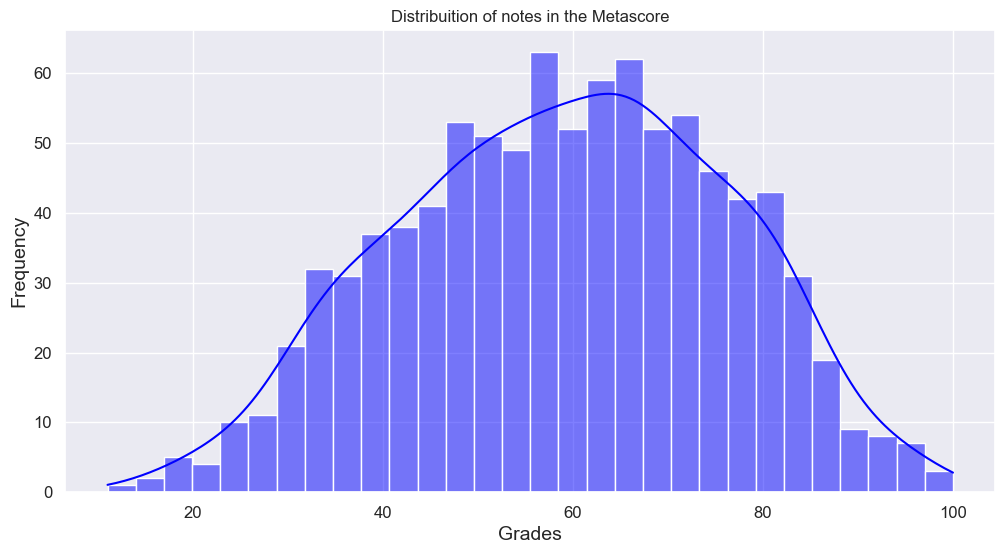

In [281]:
#Plotting the distribuiton of the Metascore grades
sns.set_theme()
plt.figure(figsize=(12,6))
sns.histplot(data=IMDB_movies['Metascore'], bins=30,kde=True,color='blue')

plt.title("Distribuition of notes in the Metascore")
plt.xlabel("Grades", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


- The Metascore grades given to all movies is following a normal distribution.

In [277]:
#Filtering the data to get the total Revenue in millions per director

revenue_per_director = IMDB_movies.groupby('Director')['RevenueMillions'].sum()

top_10_revenue_per_director = revenue_per_director.nlargest(10)

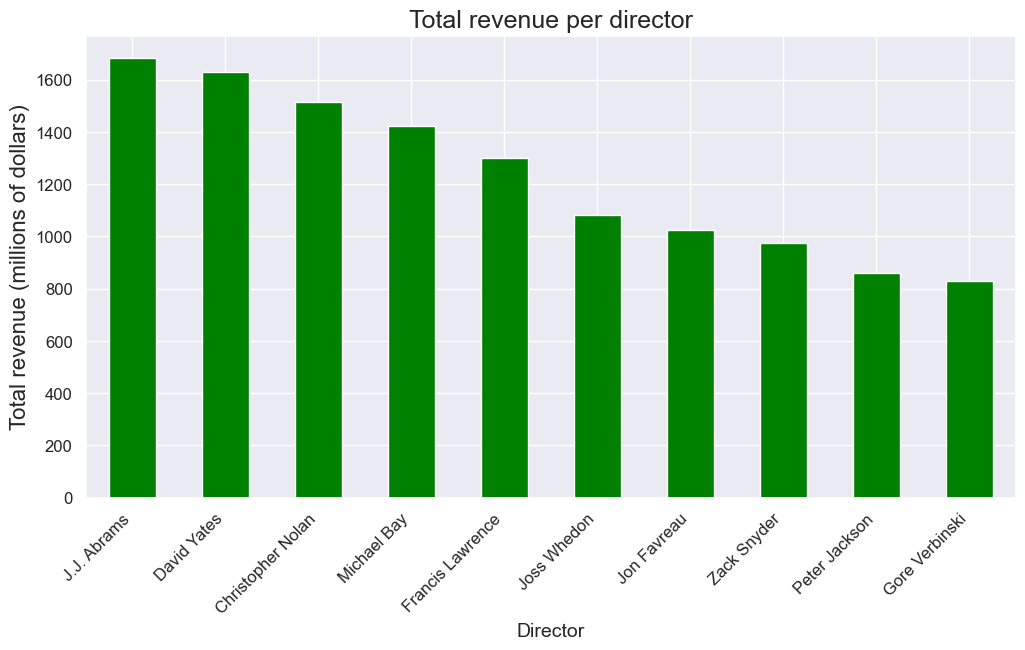

In [291]:
#Plotting the total revenue of the top 10 directors
plt.figure(figsize=(12,6))
top_10_revenue_per_director.plot(kind='bar',color='green')
plt.title("Total revenue per director",fontsize=18)
plt.xlabel('Director', fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Total revenue (millions of dollars)', fontsize=16)
plt.show()

- It is interesting to know which directos had got the most revenue during all the time considering the dataset available.

In [ ]:
#Filtering the data to get the average Revenue in millions per genre

average_revenue_per_genre = IMDB_movies.groupby('Genre')['RevenueMillions'].mean()

top_10_revenue_per_genre = average_revenue_per_genre.nlargest(10)

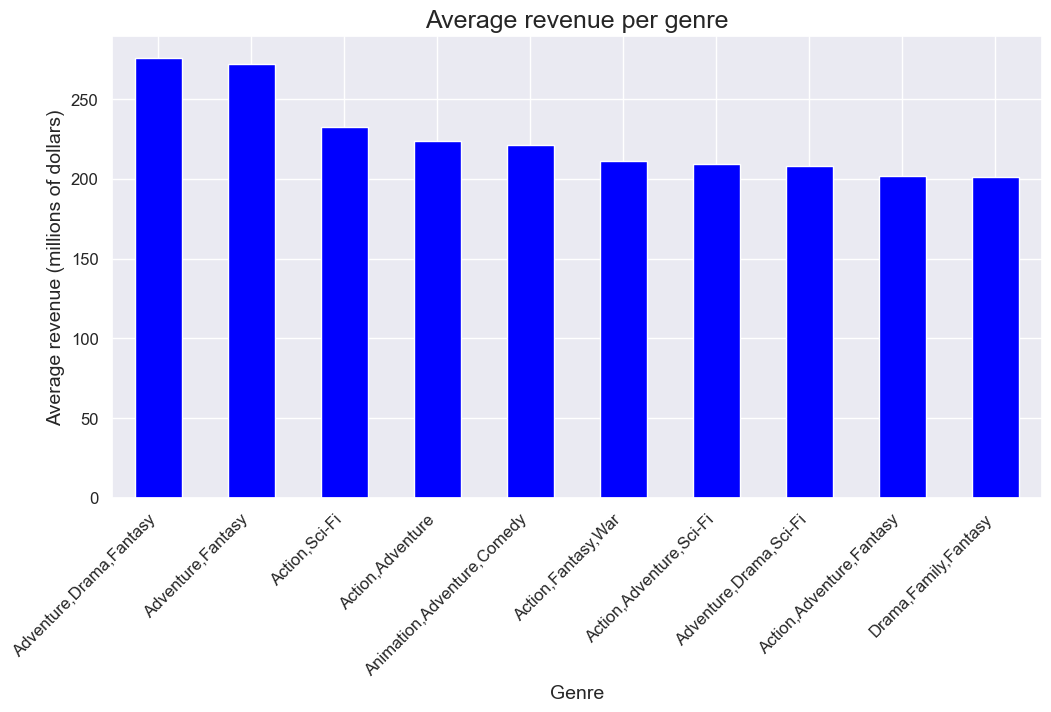

In [289]:
#Plotting the average revenue of the top 10 Genre
plt.figure(figsize=(12,6))
top_10_revenue_per_genre.plot(kind='bar',color='blue')
plt.title("Average revenue per genre", fontsize=18)
plt.xlabel('Genre', fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Average revenue (millions of dollars)', fontsize=14)
plt.show()

- In average we can see that movies classified as "Adventure, Drama and Fantasy" got an average revenue superior to 250 million dollars. But, can we get the same situation if we sum these values?

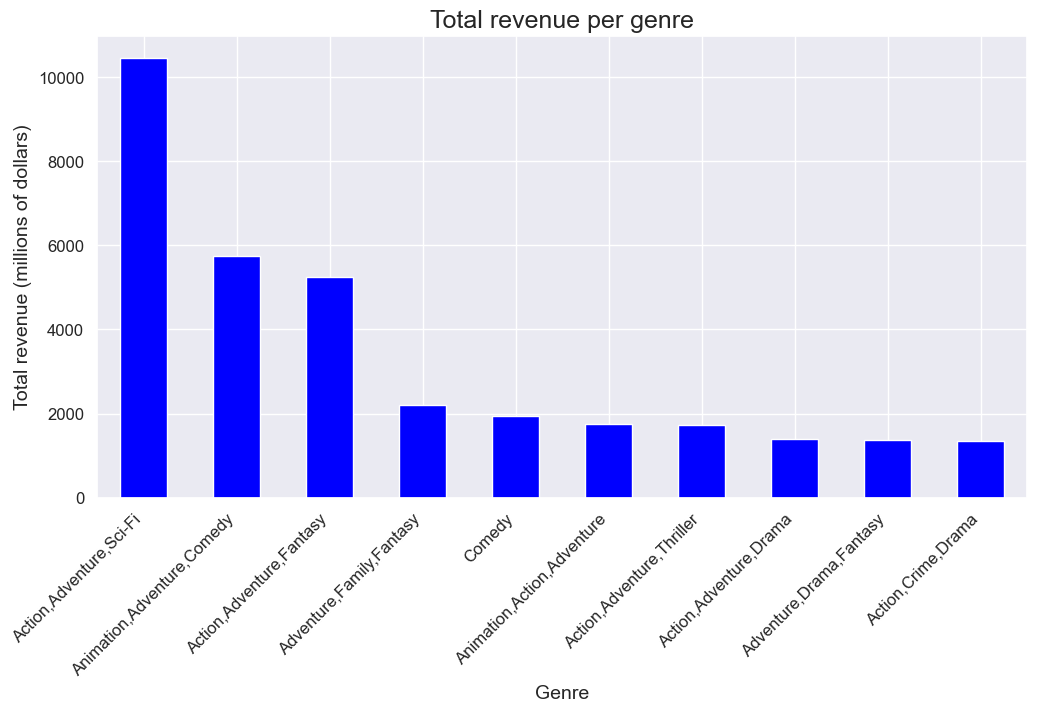

In [288]:
#Filtering the data to get the total Revenue in millions per genre

total_revenue_per_genre = IMDB_movies.groupby('Genre')['RevenueMillions'].sum()

top_10_total_revenue_per_genre = total_revenue_per_genre.nlargest(10)

#Plotting the average revenue of the top 10 Genre
plt.figure(figsize=(12,6))
top_10_total_revenue_per_genre.plot(kind='bar',color='blue')
plt.title("Total revenue per genre", fontsize=18)
plt.xlabel('Genre', fontsize=14)
plt.xticks(rotation=45, ha='right',fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel('Total revenue (millions of dollars)', fontsize=14)
plt.show()


- We can see that the scenario changes when we consider the total revenue, where now we have "Action, Adventure and Sci-Fi" as the first genre classification in the top 10, whereas "Adventure, Drama and Fantasy" is on 9th place.